In [1]:
%cd /content
!git clone --branch exp/latent-experts-k8 https://github.com/Matiata/maxim.git
%cd /content/maxim
!pip install -r requirements.txt
!pip install -e .
%pip install -q --upgrade "jax[cuda12]==0.10.2" "flax==0.11.2"
# %rm -rf /content/maxim

/content
Cloning into 'maxim'...
remote: Enumerating objects: 643, done.
remote: Counting objects: 100% (235/235), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 643 (delta 149), reused 177 (delta 102), pack-reused 408 (from 1)
Receiving objects: 100% (643/643), 40.95 MiB | 20.09 MiB/s, done.
Resolving deltas: 100% (372/372), done.
/content/maxim
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.

In [2]:
from google.colab import drive # works only for colab
drive.mount('/content/gdrive/',)

Mounted at /content/gdrive/


In [3]:
import importlib
import collections
import json
import ml_collections
import io
import time
import os
import sys
import jax.numpy as jnp
import numpy as np
import tensorflow as tf
import functools
import jax
from jax import random
from PIL import Image
from flax.core import freeze, unfreeze
from flax.traverse_util import flatten_dict, unflatten_dict
from flax.training import train_state, checkpoints
from typing import Any, Callable, Sequence, Tuple, Dict
import optax
from absl import logging
from maxim.evaluation_metrics import (
    SELECTION_METRIC, aggregate_task_psnr, build_best_metric_payload,
    read_selection_value,
)

# Runtime configuration

In [4]:
# Constants
BATCH_SIZE = 2
EVAL_BATCH_SIZE = 1
NUM_EPOCHS = 30
LEARNING_RATE = 2e-4
WARMUP_EPOCHS = 3
PATCH_SIZE = 256
LOG_EVERY = 10
SAVE_EVERY = 2
EVAL_LOG_EVERY = 100
MAX_EVAL_BATCHES = None
SEED = 42
NUM_EXPERTS = 8
TOP_K = 2
TOKEN_ROUTER_HIDDEN_FEATURES = 128
TOKEN_EXPERT_HIDDEN_MULTIPLIER = 2.0
ROUTER_TEMPERATURE = 1.0
ROUTER_NOISE_STD = 0.05
DENSE_ROUTING_WARMUP_EPOCHS = 2
ROUTER_ENTROPY_WEIGHT = 0.0
ROUTER_BALANCE_WEIGHT = 0.01
AUXILIARY_LOSS_WEIGHT = 1.0
STEPS_PER_EPOCH_OVERRIDE = 2000
WEIGHT_DECAY = 1e-4
EVAL_PATCH_SIZE = PATCH_SIZE
MODEL_VARIANT = "S-2"
OUTPUT_DIR = "/content/gdrive/MyDrive/Facultad/tesis/ckpts/moe_token_choice_k8_top2_S-2_scratch"
CHECKPOINT_SELECTION_METRIC = SELECTION_METRIC
BEST_WEIGHTED_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "best_weighted_checkpoint")
TRAIN_LOG_PATH = os.path.join(OUTPUT_DIR, "training.log")
ALLOW_OVERWRITE_EXISTING_RUN = False
RUN_PREFLIGHT = True
RUN_GRADIENT_PREFLIGHT = True
DATASET_DIR = "/content/maxim/dataset"
_MODEL_CONFIGS = {
    "variant": "",
    "dropout_rate": 0.1,
    "num_outputs": 3,
    "use_bias": True,
    "num_supervision_scales": 3,
}
SAMPLING_MODE = "uniform"
TASK_DIRS = [
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/denoise",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/derain",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/enhance",
]
TASK_NAMES = tuple(os.path.basename(os.path.normpath(path)) for path in TASK_DIRS)
NUM_TASKS = len(TASK_NAMES)
assert TASK_NAMES == ("deblur", "dehaze", "denoise", "derain", "enhance")
assert MODEL_VARIANT == "S-2"
assert NUM_EXPERTS == 8
assert TOP_K == 2
assert ROUTER_TEMPERATURE > 0
assert ROUTER_NOISE_STD >= 0
assert DENSE_ROUTING_WARMUP_EPOCHS >= 0
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(
    f"TOKEN-CHOICE RUN | {MODEL_VARIANT=} | K={NUM_EXPERTS} | top_k={TOP_K} | "
    f"dense_warmup={DENSE_ROUTING_WARMUP_EPOCHS} epochs | "
    f"steps/epoch={STEPS_PER_EPOCH_OVERRIDE}"
)


TOKEN-CHOICE RUN | MODEL_VARIANT='S-2' | K=8 | top_k=2 | dense_warmup=2 epochs | steps/epoch=2000


# Trainer helpers

In [5]:
class TrainState(train_state.TrainState):
    """Extended train state with batch statistics."""

    batch_stats: Any = None


def resize_to_match(image, target):
    """Resize image to match target dimensions using padding."""
    h, w = image.shape[0], image.shape[1]
    th, tw = target.shape[0], target.shape[1]

    # Check for transposed dimensions
    if h == tw and w == th:
        image = np.rot90(image)

    # Pad if smaller
    pad_h = max(0, th - h)
    pad_w = max(0, tw - w)
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')

    # Crop if bigger
    if h > th or w > tw:
        # Center crop
        top = (h - th) // 2
        left = (w - tw) // 2
        image = image[top:top+th, left:left+tw]

    return image


def random_crop(image, target, crop_size):
    """
    Random crop with security padding if the image is smaller than the crop size.
    Also check target shape, in some cases train/GT are mixed in verical/horizontal format.
    """
    h_i, w_i = image.shape[0], image.shape[1]
    h_t, w_t = target.shape[0], target.shape[1]

    # 1. Calculate necessary padding if the image is smaller than the crop
    pad_h_i = max(0, crop_size - h_i)
    pad_w_i = max(0, crop_size - w_i)
    pad_h_t = max(0, crop_size - h_t)
    pad_w_t = max(0, crop_size - w_t)

    if pad_h_i > 0 or pad_w_i > 0:
        print("padding image", pad_h_i, pad_w_i)
        # Use reflect padding to avoid black borders
        image = np.pad(image, ((0, pad_h_i), (0, pad_w_i), (0, 0)), mode="reflect")
        # Actualizamos dimensiones
        h_i, w_i = image.shape[0], image.shape[1]
    if pad_h_t > 0 or pad_w_t > 0:
        print("padding target", pad_h_t, pad_w_t)
        target = np.pad(target, ((0, pad_h_t), (0, pad_w_t), (0, 0)), mode="reflect")
        # Actualizamos dimensiones
        h_t, w_t = target.shape[0], target.shape[1]

    # 2. Crop: a SINGLE (top, left) shared by image and target so both patches
    #    stay spatially aligned.
    h = min(h_i, h_t)
    w = min(w_i, w_t)
    top = np.random.randint(0, h - crop_size + 1)
    left = np.random.randint(0, w - crop_size + 1)
    image = image[top : top + crop_size, left : left + crop_size]
    target = target[top : top + crop_size, left : left + crop_size]

    return image, target


def center_crop(image, target, crop_size):
    """Deterministic spatially aligned crop for validation."""
    h_i, w_i = image.shape[:2]
    h_t, w_t = target.shape[:2]
    if h_i < crop_size or w_i < crop_size:
        image = np.pad(
            image,
            ((0, max(0, crop_size - h_i)), (0, max(0, crop_size - w_i)), (0, 0)),
            mode="reflect",
        )
    if h_t < crop_size or w_t < crop_size:
        target = np.pad(
            target,
            ((0, max(0, crop_size - h_t)), (0, max(0, crop_size - w_t)), (0, 0)),
            mode="reflect",
        )
    h = min(image.shape[0], target.shape[0])
    w = min(image.shape[1], target.shape[1])
    top = max(0, (h - crop_size) // 2)
    left = max(0, (w - crop_size) // 2)
    return (
        image[top : top + crop_size, left : left + crop_size],
        target[top : top + crop_size, left : left + crop_size],
    )


def random_flip(image, target):
    """Random horizontal and vertical flip."""
    if np.random.rand() > 0.5:
        image = np.fliplr(image)
        target = np.fliplr(target)

    if np.random.rand() > 0.5:
        image = np.flipud(image)
        target = np.flipud(target)

    return image, target


def random_rotation(image, target):
    """Random 90-degree rotation."""
    k = np.random.randint(0, 4)
    image = np.rot90(image, k=k)
    target = np.rot90(target, k=k)
    return image, target


def mod_padding_symmetric(image, factor=64):
    """Pad image so H and W are divisible by factor, using symmetric reflect padding."""
    height, width = image.shape[0], image.shape[1]

    pad_h = (factor - height % factor) % factor
    pad_w = (factor - width % factor) % factor

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    image = np.pad(
        image,
        [(pad_top, pad_bottom), (pad_left, pad_right), (0, 0)],
        mode="reflect",
    )
    return image


def set_shapes(inp, tgt, sizes):
    inp.set_shape([PATCH_SIZE, PATCH_SIZE, 3])
    tgt.set_shape([PATCH_SIZE, PATCH_SIZE, 3])
    sizes.set_shape([6])
    return inp, tgt, sizes


def read_lines_from_file(basepath, filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    existing = []
    missing = []

    for line in lines:
        p = os.path.join(basepath, line)
        if os.path.exists(p):
            existing.append(p)
        else:
            missing.append(p)

    print(
        f"Checked {len(lines)} files in {basepath}: {len(existing)} existing, {len(missing)} missing."
    )
    print(f"Missing files: {missing}")

    return existing, missing


def load_image(filepath, max_retries=5, retry_delay=0.2):
    """Load an RGB image, retrying transient Google Drive I/O errors."""
    last_error = None
    for attempt in range(max_retries):
        try:
            with Image.open(filepath) as img:
                return np.asarray(img.convert("RGB"), np.float32) / 255.0
        except OSError as error:
            last_error = error
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
    raise OSError(
        f"Failed to read image after {max_retries} attempts: {filepath}"
    ) from last_error


def create_dataset(data_dir, batch_size, patch_size, split_name, is_training):
    """Create one explicit train/validation/test TensorFlow dataset."""
    if split_name not in {"train", "val", "test"}:
        raise ValueError(f"Unsupported dataset split: {split_name!r}")
    if is_training != (split_name == "train"):
        raise ValueError("Only train.txt may use training augmentation.")
    print(f"Creating {split_name} dataset from {data_dir}")
    input_dir = os.path.join(data_dir, "imgs")
    target_dir = os.path.join(data_dir, "GT")
    files_list = os.path.join(data_dir, f"{split_name}.txt")
    if not os.path.isfile(files_list):
        raise FileNotFoundError(
            f"Missing required {split_name} split: {files_list}. "
            "Create the split with the versioned scene-grouped script; "
            "the notebook will not derive it silently."
        )

    input_files, missing_inputs = read_lines_from_file(input_dir, files_list)
    target_files, missing_targets = read_lines_from_file(target_dir, files_list)
    if missing_inputs or missing_targets:
        raise FileNotFoundError(
            f"Dataset lists contain missing files in {data_dir}."
        )
    if len(input_files) != len(target_files):
        raise ValueError(f"Input/GT count mismatch in {data_dir}.")

    def load_and_preprocess(input_path, target_path):
        """Load and preprocess a single pair of images."""
        input_img = load_image(input_path.numpy().decode())
        target_img = load_image(target_path.numpy().decode())
        orig_h, orig_w = input_img.shape[:2]

        if is_training:
            # --- TRAINING FLOW ---
            # 1. Smart Random Crop (includes padding if the img is too small)
            input_img, target_img = random_crop(input_img, target_img, patch_size)

            # 2. Augmentations (Flip/Rotate)
            input_img, target_img = random_flip(input_img, target_img)
            input_img, target_img = random_rotation(input_img, target_img)

            # In training, the patch_size is already a multiple of 64.
            # No need for modd_padding_symmetric here.
            pad_h, pad_w = input_img.shape[:2]  # == patch_size
            even_h, even_w = pad_h, pad_w
        else:
            # Fixed center crop: repeated validation evaluates identical pixels.
            input_img, target_img = center_crop(input_img, target_img, patch_size)

            pad_h, pad_w = input_img.shape[:2]
            even_h, even_w = pad_h, pad_w

        # --- SAFETY CHECK / VALIDATION ---
        final_h_i, final_w_i = input_img.shape[:2]
        final_h_t, final_w_t = target_img.shape[:2]

        # Get filename for debugging (crucial to find the corrupt image)
        # We try/except because sometimes paths are not available in certain pipeline stages
        try:
            fname_i = input_path.numpy().decode('utf-8')
            fname_t = target_path.numpy().decode('utf-8')
        except:
            fname_i = "Unknown file"
            fname_t = "Unknown file"

        if is_training:
            # STRICT MODE: Training images MUST match patch_size exactly
            if final_h_i != patch_size or final_w_i != patch_size:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Training Shape!\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Expected: ({patch_size}, {patch_size})\n"
                    f"Actual:   ({final_h_i}, {final_w_i})\n"
                    f"Check your random_crop logic or if training image is too small."
                )
                print(error_msg) # Print to console so you see it in logs
                raise ValueError(error_msg) # Stop training immediately
            if final_h_t != patch_size or final_w_t != patch_size:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Training Shape!\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Expected: ({patch_size}, {patch_size})\n"
                    f"Actual:   ({final_h_t}, {final_w_t})\n"
                    f"Check your random_crop logic or if GT image is too small."
                )
                print(error_msg)
                raise ValueError(error_msg)


        else:
            # VALIDATION MODE: Images MUST be divisible by 64 (for MAXIM)
            if final_h_i % 64 != 0 or final_w_i % 64 != 0:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Validation Shape (Not divisible by 64)! Training image\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Actual:   ({final_h_i}, {final_w_i})\n"
                    f"Remainder: ({final_h_i % 64}, {final_w_i % 64})\n"
                )
                print(error_msg)
                raise ValueError(error_msg)
            if final_h_t % 64 != 0 or final_w_t % 64 != 0:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Validation Shape (Not divisible by 64)! GT image\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Actual:   ({final_h_t}, {final_w_t})\n"
                    f"Remainder: ({final_h_t % 64}, {final_w_t % 64})\n"
                )
                print(error_msg)
                raise ValueError(error_msg)

        return (
            input_img.astype(np.float32),
            target_img.astype(np.float32),
            np.array([orig_h, orig_w, even_h, even_w, pad_h, pad_w], np.int32),
        )

    dataset = tf.data.Dataset.from_tensor_slices((input_files, target_files))

    if is_training:
        dataset = dataset.shuffle(
            buffer_size=1000, seed=SEED, reshuffle_each_iteration=True
        )

    parallel_reads = min(4, os.cpu_count() or 1)
    dataset = dataset.map(
        lambda x, y: tf.py_function(
            func=load_and_preprocess,
            inp=[x, y],
            Tout=[tf.float32, tf.float32, tf.int32],
        ),
        num_parallel_calls=parallel_reads,
        deterministic=True,
    )
    dataset = dataset.map(
        set_shapes, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True
    )

    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset, len(input_files)


def resize_target_to(pred, target):
    """Downsample target if necessary to match prediction shape."""
    if pred.shape == target.shape:
        return target
    # Compute integer stride factors
    scale_h = target.shape[1] // pred.shape[1]
    scale_w = target.shape[2] // pred.shape[2]
    # Subsample target by simple stride (fast, deterministic)
    return target[:, ::scale_h, ::scale_w, :]


def compute_psnr_per_example(pred, target):
    """Return one PSNR value per image, assuming a [0, 1] range."""
    pred_255 = pred * 255.0
    target_255 = target * 255.0
    diff = pred_255 - target_255
    mse = jnp.mean(diff ** 2, axis=(1, 2, 3))
    mse = jnp.maximum(mse, 1e-6)
    return 20.0 * jnp.log10(255.0 / jnp.sqrt(mse))


def compute_psnr(pred, target):
    return jnp.mean(compute_psnr_per_example(pred, target))


def create_learning_rate_schedule(base_lr, warmup_epochs, total_steps, steps_per_epoch):
    """Create learning rate schedule with warmup and cosine decay."""
    warmup_steps = warmup_epochs * steps_per_epoch

    warmup_fn = optax.linear_schedule(
        init_value=0.0, end_value=base_lr, transition_steps=warmup_steps
    )

    cosine_fn = optax.cosine_decay_schedule(
        init_value=base_lr, decay_steps=total_steps - warmup_steps, alpha=1e-6
    )

    schedule_fn = optax.join_schedules(
        schedules=[warmup_fn, cosine_fn], boundaries=[warmup_steps]
    )

    return schedule_fn


def router_entropy_loss(dense_probs, eps=1e-8):
    """Mean entropy over B x N independent token decisions."""
    return -jnp.mean(jnp.sum(dense_probs * jnp.log(dense_probs + eps), axis=-1))


def load_balance_loss(dense_probs):
    """Dense pre-top-k balance; gradients reach every router logit."""
    usage = jnp.mean(dense_probs, axis=(0, 1))
    return dense_probs.shape[-1] * jnp.sum(usage**2)


def _tree_l2_norm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.asarray(0.0, dtype=jnp.float32)
    return jnp.sqrt(sum(jnp.sum(jnp.square(leaf)) for leaf in leaves))


def gradient_statistics(grads):
    router_norm = _tree_l2_norm(grads.get("router", {}))
    expert_norms = jnp.stack([
        _tree_l2_norm(grads.get(f"experts_{index}", {}))
        for index in range(NUM_EXPERTS)
    ])
    return router_norm, expert_norms


def router_batch_statistics(
    dense_probs, sparse_gates, task_ids, sample_psnr, sample_final_loss, eps=1e-8
):
    """Additive image and token statistics for exact epoch aggregation."""
    task_ids = jnp.asarray(task_ids, dtype=jnp.int32).reshape(-1)
    batch_size, tokens_per_image, _ = dense_probs.shape
    token_count = batch_size * tokens_per_image
    token_entropy = -jnp.sum(dense_probs * jnp.log(dense_probs + eps), axis=-1)
    token_confidence = jnp.max(dense_probs, axis=-1)
    top1 = jnp.argmax(sparse_gates, axis=-1)
    top1_one_hot = jax.nn.one_hot(top1, NUM_EXPERTS, dtype=dense_probs.dtype)
    _, top_indices = jax.lax.top_k(sparse_gates, TOP_K)
    topk_inclusion = jnp.sum(
        jax.nn.one_hot(top_indices, NUM_EXPERTS, dtype=dense_probs.dtype), axis=-2
    )

    pair_left = jnp.minimum(top_indices[..., 0], top_indices[..., 1])
    pair_right = jnp.maximum(top_indices[..., 0], top_indices[..., 1])
    pair_ids = pair_left * NUM_EXPERTS + pair_right
    pair_count = jnp.sum(
        jax.nn.one_hot(pair_ids, NUM_EXPERTS * NUM_EXPERTS, dtype=dense_probs.dtype),
        axis=(0, 1),
    ).reshape(NUM_EXPERTS, NUM_EXPERTS)

    task_one_hot = jax.nn.one_hot(task_ids, NUM_TASKS, dtype=dense_probs.dtype)
    dense_per_image = jnp.sum(dense_probs, axis=1)
    sparse_per_image = jnp.sum(sparse_gates, axis=1)
    top1_per_image = jnp.sum(top1_one_hot, axis=1)
    topk_per_image = jnp.sum(topk_inclusion, axis=1)
    entropy_per_image_sum = jnp.sum(token_entropy, axis=1)
    confidence_per_image_sum = jnp.sum(token_confidence, axis=1)
    sample_psnr = jnp.asarray(sample_psnr).reshape(-1)
    sample_final_loss = jnp.asarray(sample_final_loss).reshape(-1)

    return {
        "sample_count": jnp.asarray(batch_size, dtype=dense_probs.dtype),
        "token_count": jnp.asarray(token_count, dtype=dense_probs.dtype),
        "tokens_per_image": jnp.asarray(tokens_per_image, dtype=dense_probs.dtype),
        "router_dense_prob_sum": jnp.sum(dense_probs, axis=(0, 1)),
        "router_sparse_gate_sum": jnp.sum(sparse_gates, axis=(0, 1)),
        "router_top1_count": jnp.sum(top1_one_hot, axis=(0, 1)),
        "router_topk_count": jnp.sum(topk_inclusion, axis=(0, 1)),
        "router_pair_count": pair_count,
        "router_token_entropy_sum": jnp.sum(token_entropy),
        "router_image_entropy_sum": jnp.sum(jnp.mean(token_entropy, axis=1)),
        "router_confidence_sum": jnp.sum(token_confidence),
        "task_count": jnp.sum(task_one_hot, axis=0),
        "task_token_count": jnp.sum(task_one_hot, axis=0) * tokens_per_image,
        "task_expert_dense_sum": task_one_hot.T @ dense_per_image,
        "task_expert_sparse_sum": task_one_hot.T @ sparse_per_image,
        "task_top1_count": task_one_hot.T @ top1_per_image,
        "task_topk_count": task_one_hot.T @ topk_per_image,
        "task_token_entropy_sum": task_one_hot.T @ entropy_per_image_sum,
        "task_token_confidence_sum": task_one_hot.T @ confidence_per_image_sum,
        "task_psnr_sum": task_one_hot.T @ sample_psnr,
        "task_final_loss_sum": task_one_hot.T @ sample_final_loss,
    }


def summarize_router_metrics(batch_metrics):
    if not batch_metrics:
        return {}

    sample_counts = np.asarray([float(m["sample_count"]) for m in batch_metrics])
    total_samples = float(np.sum(sample_counts))
    total_tokens = float(sum(float(m["token_count"]) for m in batch_metrics))

    def weighted_mean(key):
        values = np.asarray([float(m[key]) for m in batch_metrics])
        return float(np.sum(values * sample_counts) / total_samples)

    def weighted_vector_mean(key):
        values = np.stack([np.asarray(m[key]) for m in batch_metrics])
        return np.sum(values * sample_counts[:, None], axis=0) / total_samples

    def summed(key):
        return np.sum(np.stack([np.asarray(m[key]) for m in batch_metrics]), axis=0)

    dense_usage = summed("router_dense_prob_sum") / total_tokens
    sparse_load = summed("router_sparse_gate_sum") / total_tokens
    top1_frequency = summed("router_top1_count") / total_tokens
    topk_frequency = summed("router_topk_count") / total_tokens
    pair_frequency = summed("router_pair_count") / total_tokens
    task_count = summed("task_count")
    task_token_count = summed("task_token_count")
    token_entropy = float(
        sum(float(m["router_token_entropy_sum"]) for m in batch_metrics) / total_tokens
    )
    image_entropy = float(
        sum(float(m["router_image_entropy_sum"]) for m in batch_metrics) / total_samples
    )
    confidence = float(
        sum(float(m["router_confidence_sum"]) for m in batch_metrics) / total_tokens
    )
    global_entropy = float(-np.sum(dense_usage * np.log(dense_usage + 1e-8)))

    def task_token_average(key):
        numerator = summed(key)
        denominator = task_token_count[:, None]
        return np.divide(
            numerator, denominator,
            out=np.full_like(numerator, np.nan, dtype=np.float64),
            where=denominator > 0,
        )

    task_entropy = np.divide(
        summed("task_token_entropy_sum"), task_token_count,
        out=np.full(NUM_TASKS, np.nan), where=task_token_count > 0,
    )
    task_confidence = np.divide(
        summed("task_token_confidence_sum"), task_token_count,
        out=np.full(NUM_TASKS, np.nan), where=task_token_count > 0,
    )
    psnr_metrics = aggregate_task_psnr(summed("task_psnr_sum"), task_count)
    task_final_loss = np.divide(
        summed("task_final_loss_sum"), task_count,
        out=np.full(NUM_TASKS, np.nan), where=task_count > 0,
    )

    return {
        "loss": weighted_mean("loss"),
        "reconstruction_loss": weighted_mean("reconstruction_loss"),
        "final_loss": weighted_mean("final_loss"),
        "auxiliary_loss": weighted_mean("auxiliary_loss"),
        "psnr_weighted": psnr_metrics["psnr_weighted"],
        "psnr_macro": psnr_metrics["psnr_macro"],
        "balance": weighted_mean("balance"),
        "dense_routing_fraction": weighted_mean("dense_routing_fraction"),
        "sample_count": psnr_metrics["sample_count"],
        "token_count": total_tokens,
        "router_dense_usage": dense_usage,
        "router_sparse_load": sparse_load,
        "router_top1_frequency": top1_frequency,
        "router_topk_frequency": topk_frequency,
        "router_pair_frequency": pair_frequency,
        "router_token_entropy": token_entropy,
        "router_image_entropy": image_entropy,
        "router_global_entropy": global_entropy,
        "router_effective_experts_per_token": float(np.exp(token_entropy)),
        "router_effective_experts_global": float(np.exp(global_entropy)),
        "router_confidence": confidence,
        "router_grad_norm": weighted_mean("router_grad_norm"),
        "expert_grad_norm": weighted_vector_mean("expert_grad_norm"),
        "task_count": psnr_metrics["task_count"],
        "task_token_count": task_token_count,
        "task_expert_dense_usage": task_token_average("task_expert_dense_sum"),
        "task_expert_sparse_load": task_token_average("task_expert_sparse_sum"),
        "task_top1_frequency": task_token_average("task_top1_count"),
        "task_topk_frequency": task_token_average("task_topk_count"),
        "task_entropy": task_entropy,
        "task_confidence": task_confidence,
        "task_psnr": psnr_metrics["task_psnr"],
        "task_final_loss": task_final_loss,
    }


def print_router_diagnostics(metrics, title):
    if not metrics:
        return

    def expert_vector(values):
        return "  ".join(
            f"E{idx}={float(value):.3f}" for idx, value in enumerate(values)
        )

    def expert_scientific(values):
        return "  ".join(
            f"E{idx}={float(value):.3e}" for idx, value in enumerate(values)
        )

    print(f"{title}:")
    print(f"  fraccion de batches con mezcla densa: {metrics['dense_routing_fraction']:.1%}")
    print(f"  uso soft denso/token: {expert_vector(metrics['router_dense_usage'])}")
    print(f"  carga sparse/token: {expert_vector(metrics['router_sparse_load'])}")
    print(f"  inclusion top-{TOP_K}/token: {expert_vector(metrics['router_topk_frequency'])}")
    print(f"  frecuencia top-1/token: {expert_vector(metrics['router_top1_frequency'])}")
    print(
        f"  H/token={metrics['router_token_entropy']:.4f}, "
        f"H/imagen={metrics['router_image_entropy']:.4f}, "
        f"H/global={metrics['router_global_entropy']:.4f}, "
        f"expertos efectivos token/global="
        f"{metrics['router_effective_experts_per_token']:.2f}/"
        f"{metrics['router_effective_experts_global']:.2f}, "
        f"confianza={metrics['router_confidence']:.3f}"
    )
    print(
        f"  grad router={metrics['router_grad_norm']:.3e} | "
        f"grad expertos: {expert_scientific(metrics['expert_grad_norm'])}"
    )
    pair_indices = np.argwhere(metrics["router_pair_frequency"] > 0)
    pair_entries = sorted(
        ((float(metrics["router_pair_frequency"][i, j]), int(i), int(j))
         for i, j in pair_indices), reverse=True
    )[:8]
    print("  pares top-2: " + "  ".join(
        f"E{i}/E{j}={frequency:.1%}" for frequency, i, j in pair_entries
    ))
    print("  uso soft denso tarea x experto:")
    for task_name, count, row, entropy, confidence in zip(
        TASK_NAMES, metrics["task_count"], metrics["task_expert_dense_usage"],
        metrics["task_entropy"], metrics["task_confidence"],
    ):
        print(
            f"    {task_name:>8s} (images={int(count):5d}): {expert_vector(row)}  "
            f"H={float(entropy):.3f} max={float(confidence):.3f}"
        )
    print(f"  inclusion top-{TOP_K} tarea x experto:")
    for task_name, count, row in zip(
        TASK_NAMES, metrics["task_count"], metrics["task_topk_frequency"],
    ):
        print(f"    {task_name:>8s} (images={int(count):5d}): {expert_vector(row)}")
    print("  calidad final por tarea:")
    for task_name, count, psnr, final_loss in zip(
        TASK_NAMES, metrics["task_count"], metrics["task_psnr"],
        metrics["task_final_loss"],
    ):
        print(
            f"    {task_name:>8s} (n={int(count):5d}): "
            f"PSNR={float(psnr):7.2f} dB final_L1={float(final_loss):.5f}"
        )


def _jsonable_metrics(metrics):
    return {
        key: value.tolist() if isinstance(value, np.ndarray) else value
        for key, value in metrics.items()
    }


def save_router_diagnostics(
    epoch, train_metrics, val_metrics, output_dir, effective_steps_per_epoch
):
    """Persist one JSON per epoch next to the model checkpoints."""
    diagnostics_dir = os.path.join(output_dir, "router_diagnostics")
    os.makedirs(diagnostics_dir, exist_ok=True)
    path = os.path.join(diagnostics_dir, f"epoch_{epoch:03d}.json")
    payload = {
        "epoch": int(epoch),
        "selection_metric": CHECKPOINT_SELECTION_METRIC,
        "routing_mode": "token_choice",
        "task_names": list(TASK_NAMES),
        "num_experts": NUM_EXPERTS,
        "top_k": TOP_K,
        "task_to_expert": None,
        "router_entropy_weight": ROUTER_ENTROPY_WEIGHT,
        "router_granularity": "token",
        "router_input": "final_decoder_features",
        "router_temperature": ROUTER_TEMPERATURE,
        "router_noise_std": ROUTER_NOISE_STD,
        "dense_routing_warmup_epochs": DENSE_ROUTING_WARMUP_EPOCHS,
        "token_router_hidden_features": TOKEN_ROUTER_HIDDEN_FEATURES,
        "token_expert_hidden_multiplier": TOKEN_EXPERT_HIDDEN_MULTIPLIER,
        "router_granularity": "token",
        "router_input": "final_decoder_features",
        "router_temperature": ROUTER_TEMPERATURE,
        "router_noise_std": ROUTER_NOISE_STD,
        "dense_routing_warmup_epochs": DENSE_ROUTING_WARMUP_EPOCHS,
        "token_router_hidden_features": TOKEN_ROUTER_HIDDEN_FEATURES,
        "token_expert_hidden_multiplier": TOKEN_EXPERT_HIDDEN_MULTIPLIER,
        "router_balance_weight": ROUTER_BALANCE_WEIGHT,
        "model_variant": MODEL_VARIANT,
        "dropout_rate": _MODEL_CONFIGS["dropout_rate"],
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "steps_per_epoch": int(effective_steps_per_epoch),
        "num_epochs": NUM_EPOCHS,
        "patch_size": PATCH_SIZE,
        "sampling_mode_train": SAMPLING_MODE,
        "load_maxim_backbone": LOAD_MAXIM_BACKBONE,
        "train": _jsonable_metrics(train_metrics),
        "validation": _jsonable_metrics(val_metrics),
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    print(f"Router diagnostics saved to {path}")


def save_router_heatmaps(epoch, train_metrics, val_metrics, output_dir):
    """Save soft-usage and top-1 task/expert heatmaps for one epoch."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib no esta disponible; se omite el heatmap del router.")
        return

    diagnostics_dir = os.path.join(output_dir, "router_diagnostics")
    os.makedirs(diagnostics_dir, exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    panels = (
        (axes[0, 0], train_metrics["task_expert_dense_usage"], "Train: uso soft/token"),
        (axes[0, 1], train_metrics["task_topk_frequency"], "Train: inclusion top-2/token"),
        (axes[1, 0], val_metrics["task_expert_dense_usage"], "Validacion: uso soft/token"),
        (axes[1, 1], val_metrics["task_topk_frequency"], "Validacion: inclusion top-2/token"),
    )
    image = None
    for ax, matrix, title in panels:
        matrix = np.asarray(matrix, dtype=np.float64)
        image = ax.imshow(np.nan_to_num(matrix), vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_title(title)
        ax.set_xlabel("Experto")
        ax.set_ylabel("Tarea")
        ax.set_xticks(range(NUM_EXPERTS), [f"E{i}" for i in range(NUM_EXPERTS)])
        ax.set_yticks(range(NUM_TASKS), TASK_NAMES)
        for task_idx in range(NUM_TASKS):
            for expert_idx in range(NUM_EXPERTS):
                value = matrix[task_idx, expert_idx]
                label = "--" if np.isnan(value) else f"{value:.2f}"
                color = "white" if np.isnan(value) or value < 0.55 else "black"
                ax.text(expert_idx, task_idx, label, ha="center", va="center", color=color)
    fig.colorbar(image, ax=axes, shrink=0.8, label="Proporcion")
    fig.suptitle(
        f"Diagnostico token-choice - epoca {epoch}", fontsize=14
    )
    path = os.path.join(diagnostics_dir, f"epoch_{epoch:03d}_heatmaps.png")
    fig.savefig(path, dpi=160)
    plt.close(fig)
    print(f"Router heatmaps saved to {path}")


def compute_supervision_losses(
    predictions, targets, num_scales=3, auxiliary_weight=1.0
):
    """Separate MoE-final L1 from normalized deep-supervision L1.

    MAXIM orders each stage from the smallest scale to full resolution.
    The final full-resolution item is produced by the MoE; every other
    item remains an auxiliary MAXIM prediction.
    """
    if not isinstance(predictions, (list, tuple)) or not predictions:
        raise ValueError("Expected non-empty multi-stage predictions.")

    final_prediction = predictions[-1][-1]
    final_target = resize_target_to(final_prediction, targets)
    final_loss = jnp.mean(jnp.abs(final_prediction - final_target))

    auxiliary_sum = jnp.zeros_like(final_loss)
    auxiliary_weight_sum = 0.0
    last_stage = len(predictions) - 1
    for stage_idx, stage_predictions in enumerate(predictions):
        for scale_idx, prediction in enumerate(stage_predictions):
            is_moe_final = (
                stage_idx == last_stage
                and scale_idx == len(stage_predictions) - 1
            )
            if is_moe_final:
                continue
            scale_weight = 0.5 ** (num_scales - scale_idx - 1)
            target_at_scale = resize_target_to(prediction, targets)
            auxiliary_sum += scale_weight * jnp.mean(
                jnp.abs(prediction - target_at_scale)
            )
            auxiliary_weight_sum += scale_weight

    auxiliary_denominator = jnp.maximum(
        jnp.asarray(auxiliary_weight_sum, dtype=final_loss.dtype),
        jnp.asarray(1e-8, dtype=final_loss.dtype),
    )
    auxiliary_loss = auxiliary_sum / auxiliary_denominator
    reconstruction_loss = final_loss + auxiliary_weight * auxiliary_loss
    return reconstruction_loss, final_loss, auxiliary_loss, final_prediction


# Wrap at module scope so it compiles only once
def forward_apply(
    apply_fn, params, batch_stats, x, rngs, dense_routing
):
    variables = {"params": params}
    if batch_stats is not None:
        variables["batch_stats"] = batch_stats
        outputs, updates = apply_fn(
            variables, x, train=True, dense_routing=dense_routing,
            rngs=rngs, mutable=["batch_stats"],
        )
        return outputs, updates["batch_stats"]
    return apply_fn(
        variables, x, train=True, dense_routing=dense_routing, rngs=rngs
    ), None


@functools.partial(jax.jit, donate_argnums=(0,))
def train_step(
    state: TrainState, batch_input, batch_target, task_id, num_scales, rng,
    dense_routing,
):
    """One token-choice training step with dense pre-top-k balancing."""

    def loss_fn(params, batch_stats, x, y, task_ids, rng, dense_routing):
        rngs = {
            "dropout": rng,
            "routing": jax.random.fold_in(rng, 1),
        }
        (preds, dense_probs, sparse_gates), new_batch_stats = jax.checkpoint(
            forward_apply, static_argnums=(0,)
        )(state.apply_fn, params, batch_stats, x, rngs, dense_routing)
        reconstruction_loss, final_loss, auxiliary_loss, final_pred = (
            compute_supervision_losses(
                preds, y, num_scales, AUXILIARY_LOSS_WEIGHT
            )
        )
        entropy_loss = router_entropy_loss(dense_probs)
        balance_loss = load_balance_loss(dense_probs)
        final_target = resize_target_to(final_pred, y)
        sample_psnr = compute_psnr_per_example(final_pred, final_target)
        sample_final_loss = jnp.mean(
            jnp.abs(final_pred - final_target), axis=(1, 2, 3)
        )
        router_stats = router_batch_statistics(
            dense_probs, sparse_gates, task_ids, sample_psnr, sample_final_loss
        )
        total_loss = (
            reconstruction_loss
            - ROUTER_ENTROPY_WEIGHT * entropy_loss
            + ROUTER_BALANCE_WEIGHT * balance_loss
        )
        return total_loss, {
            "reconstruction_loss": reconstruction_loss,
            "final_loss": final_loss,
            "auxiliary_loss": auxiliary_loss,
            "psnr_batch_mean": jnp.mean(sample_psnr),
            "entropy": entropy_loss,
            "balance": balance_loss,
            "router_stats": router_stats,
            "batch_stats": new_batch_stats,
        }

    (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(
        state.params, state.batch_stats, batch_input, batch_target, task_id, rng,
        dense_routing,
    )
    router_grad_norm, expert_grad_norm = gradient_statistics(grads)
    new_state = state.apply_gradients(grads=grads)
    if aux["batch_stats"] is not None:
        new_state = new_state.replace(batch_stats=aux["batch_stats"])
    metrics = {
        "loss": loss,
        "reconstruction_loss": aux["reconstruction_loss"],
        "final_loss": aux["final_loss"],
        "auxiliary_loss": aux["auxiliary_loss"],
        "psnr_batch_mean": aux["psnr_batch_mean"],
        "entropy": aux["entropy"],
        "balance": aux["balance"],
        "router_grad_norm": router_grad_norm,
        "expert_grad_norm": expert_grad_norm,
        "dense_routing_fraction": dense_routing.astype(jnp.float32),
        **aux["router_stats"],
    }
    return new_state, metrics


def train_epoch(state, train_dataset, num_scales, epoch, steps_per_epoch):
    batch_metrics = []
    dense_routing = jnp.asarray(epoch <= DENSE_ROUTING_WARMUP_EPOCHS)
    routing_label = "dense warm-up" if bool(dense_routing) else f"top-{TOP_K}"
    print(f"Starting training epoch {epoch} | routing={routing_label}")
    for step in range(steps_per_epoch):
        try:
            batch_input, batch_target, sizes, task_id = next(train_dataset)
        except StopIteration:
            print("Dataset exhausted early!")
            break
        batch_input = jnp.array(batch_input)
        batch_target = jnp.array(batch_target)
        task_id = jnp.asarray(task_id, dtype=jnp.int32)
        if batch_input.shape != batch_target.shape:
            print(f"Skipping step {step} due to shape mismatch")
            continue
        rng = jax.random.fold_in(jax.random.PRNGKey(epoch), step)
        state, metrics = train_step(
            state, batch_input, batch_target, task_id, num_scales, rng,
            dense_routing,
        )
        metrics_np = jax.device_get(metrics)
        batch_metrics.append(metrics_np)
        if (step + 1) % LOG_EVERY == 0:
            token_count = metrics_np["token_count"]
            step_usage = metrics_np["router_dense_prob_sum"] / token_count
            step_topk = metrics_np["router_topk_count"] / token_count
            step_confidence = metrics_np["router_confidence_sum"] / token_count
            print(
                f"Epoch {epoch}, Step {step + 1}: loss={metrics_np['loss']:.4f}, "
                f"final={metrics_np['final_loss']:.4f}, "
                f"PSNR={metrics_np['psnr_batch_mean']:.2f} dB, "
                f"bal={metrics_np['balance']:.4f}, conf={step_confidence:.3f}, "
                f"dense={np.round(step_usage, 3)}, top-{TOP_K}={np.round(step_topk, 3)}"
            )
    if batch_metrics:
        epoch_metrics = summarize_router_metrics(batch_metrics)
        print_router_diagnostics(epoch_metrics, f"Epoch {epoch} train router")
    else:
        print("Advertencia: no se procesaron batches en esta epoca.")
        epoch_metrics = {}
    return state, epoch_metrics


@jax.jit
def gradient_preflight_step(state, batch_input, batch_target):
    """Check reconstruction gradients without advancing or donating state."""
    def loss_fn(params):
        variables = {"params": params}
        if state.batch_stats is not None:
            variables["batch_stats"] = state.batch_stats
        predictions, dense_probs, _ = state.apply_fn(
            variables, batch_input, train=False, dense_routing=True
        )
        reconstruction_loss, _, _, _ = compute_supervision_losses(
            predictions, batch_target,
            _MODEL_CONFIGS["num_supervision_scales"], AUXILIARY_LOSS_WEIGHT,
        )
        return reconstruction_loss + ROUTER_BALANCE_WEIGHT * load_balance_loss(
            dense_probs
        )

    grads = jax.grad(loss_fn)(state.params)
    return gradient_statistics(grads)


@jax.jit
def eval_step(state, batch_input, batch_target, task_id):
    variables = {"params": state.params}
    if state.batch_stats is not None:
        variables["batch_stats"] = state.batch_stats
    predictions, dense_probs, sparse_gates = state.apply_fn(
        variables, batch_input, train=False, dense_routing=False
    )
    reconstruction_loss, final_loss, auxiliary_loss, final_pred = (
        compute_supervision_losses(
            predictions, batch_target,
            _MODEL_CONFIGS["num_supervision_scales"], AUXILIARY_LOSS_WEIGHT,
        )
    )
    final_target = resize_target_to(final_pred, batch_target)
    sample_psnr = compute_psnr_per_example(final_pred, final_target)
    sample_final_loss = jnp.mean(
        jnp.abs(final_pred - final_target), axis=(1, 2, 3)
    )
    router_stats = router_batch_statistics(
        dense_probs, sparse_gates, task_id, sample_psnr, sample_final_loss
    )
    return {
        "loss": reconstruction_loss,
        "reconstruction_loss": reconstruction_loss,
        "final_loss": final_loss,
        "auxiliary_loss": auxiliary_loss,
        "psnr_batch_mean": jnp.mean(sample_psnr),
        "balance": load_balance_loss(dense_probs),
        "router_grad_norm": jnp.asarray(0.0),
        "expert_grad_norm": jnp.zeros((NUM_EXPERTS,)),
        "dense_routing_fraction": jnp.asarray(0.0),
        **router_stats,
    }


def evaluate(state, val_dataset, log_every=100, max_batches=None):
    batch_metrics = []
    n_batches = 0
    start = time.time()
    print("Starting evaluation with deterministic token top-2 routing...")
    for batch_input, batch_target, sizes, task_id in val_dataset:
        if max_batches is not None and n_batches >= max_batches:
            break
        metrics = jax.device_get(eval_step(
            state, jnp.asarray(batch_input), jnp.asarray(batch_target),
            jnp.asarray(task_id, dtype=jnp.int32),
        ))
        batch_metrics.append(metrics)
        n_batches += 1
        if n_batches % log_every == 0:
            elapsed = time.time() - start
            running = summarize_router_metrics(batch_metrics)
            rate = n_batches / elapsed if elapsed > 0 else 0.0
            print(
                f"  [eval] {n_batches} batches | weighted="
                f"{running['psnr_weighted']:.2f} dB, macro="
                f"{running['psnr_macro']:.2f} dB, loss={running['loss']:.4f}, "
                f"conf={running['router_confidence']:.3f} | {rate:.1f} batch/s"
            )
    if not batch_metrics:
        print("Evaluation: no batches processed.")
        return {}
    val_metrics = summarize_router_metrics(batch_metrics)
    elapsed = time.time() - start
    print(
        f"Evaluation done: {n_batches} batches in {elapsed:.1f}s | "
        f"weighted={val_metrics['psnr_weighted']:.2f} dB, "
        f"macro={val_metrics['psnr_macro']:.2f} dB, loss={val_metrics['loss']:.4f}"
    )
    print_router_diagnostics(val_metrics, "Validation router")
    return val_metrics


def create_dataset_unbatched(data_dir, patch_size, split_name, is_training):
    ds, length = create_dataset(
        data_dir=data_dir,
        batch_size=1,  # batch temporal
        patch_size=patch_size,
        split_name=split_name,
        is_training=is_training,
    )
    ds = ds.unbatch()
    return ds, length


# Add task_id (just for logging/analysis)
def add_task_id(dataset, task_id):
    task_id = tf.constant(task_id, dtype=tf.int32)
    return dataset.map(
        lambda x, y, sizes: (x, y, sizes, task_id),
        num_parallel_calls=tf.data.AUTOTUNE,
    )


def create_unified_dataset(
    task_dirs,
    batch_size,
    patch_size,
    split_name,
    is_training,
    sampling_mode="uniform",
    shuffle_buffer=1000,
):
    """
    Args:
        task_dirs: list[str] — directorios, uno por tarea
        sampling_mode (training only):
            "uniform"      -> todas las tareas equiprobables
            "proportional" -> proporcional al tamaño real
    """

    datasets = []
    lengths = []

    # Create datasets per task
    for task_id, data_dir in enumerate(task_dirs):
        ds, n = create_dataset_unbatched(
            data_dir=data_dir,
            patch_size=patch_size,
            split_name=split_name,
            is_training=is_training,
        )
        ds = add_task_id(ds, task_id)
        datasets.append(ds)
        lengths.append(n)

    total_samples = int(sum(lengths))
    lengths = tf.constant(lengths, dtype=tf.float32)
    # jax.debug.print("datasets lengths: {datasets} \n {lengths}", datasets, lengths)

    if is_training:
        if sampling_mode == "uniform":
            weights = tf.ones_like(lengths) / tf.cast(tf.size(lengths), tf.float32)
        elif sampling_mode == "proportional":
            weights = lengths / tf.reduce_sum(lengths)
        else:
            raise ValueError(f"Unknown sampling_mode: {sampling_mode}")
        # Each source must be infinite before mixing. Repeating only the mixed
        # dataset makes finite sources disappear when they are exhausted and
        # turns uniform sampling into dataset-size-proportional sampling.
        repeated_datasets = [dataset.repeat() for dataset in datasets]
        unified_ds = tf.data.Dataset.sample_from_datasets(
            repeated_datasets,
            weights=weights,
            seed=SEED,
            stop_on_empty_dataset=False,
        )
        unified_ds = unified_ds.shuffle(
            shuffle_buffer, seed=SEED, reshuffle_each_iteration=True
        )
    else:
        # Concatenation guarantees deterministic, exhaustive task coverage.
        unified_ds = datasets[0]
        for task_dataset in datasets[1:]:
            unified_ds = unified_ds.concatenate(task_dataset)

    unified_ds = unified_ds.batch(batch_size, drop_remainder=is_training)
    unified_ds = unified_ds.prefetch(tf.data.AUTOTUNE)

    if not is_training:
        steps_per_epoch = (total_samples + batch_size - 1) // batch_size
    elif STEPS_PER_EPOCH_OVERRIDE is not None:
        steps_per_epoch = int(STEPS_PER_EPOCH_OVERRIDE)
    else:
        steps_per_epoch = max(1, total_samples // batch_size)

    return unified_ds, steps_per_epoch

In [6]:
def recover_tree(keys, values):
    """Recovers a tree as a nested dict from flat names and values.

    This function is useful to analyze checkpoints that are saved by our programs
    without need to access the exact source code of the experiment. In particular,
    it can be used to extract an reuse various subtrees of the scheckpoint, e.g.
    subtree of parameters.
    Args:
      keys: a list of keys, where '/' is used as separator between nodes.
      values: a list of leaf values.
    Returns:
      A nested tree-like dict.
    """
    tree = {}
    sub_trees = collections.defaultdict(list)
    for k, v in zip(keys, values):
        if "/" not in k:
            tree[k] = v
        else:
            k_left, k_right = k.split("/", 1)
            sub_trees[k_left].append((k_right, v))
    for k, kv_pairs in sub_trees.items():
        k_subtree, v_subtree = zip(*kv_pairs)
        tree[k] = recover_tree(k_subtree, v_subtree)
    return tree


def get_params(ckpt_path):
    """Get params checkpoint."""

    with tf.io.gfile.GFile(ckpt_path, "rb") as f:
        data = f.read()
    values = np.load(io.BytesIO(data))
    params = recover_tree(*zip(*values.items()))
    params = params["opt"]["target"]

    return params


def load_maxim_backbone(params_moe, params_maxim):
    moe = unfreeze(params_moe)
    flat_moe = flatten_dict(moe)
    flat_maxim = flatten_dict(params_maxim)

    for k, v in flat_maxim.items():
        if k in flat_moe and flat_moe[k].shape == v.shape:
            flat_moe[k] = v

    return freeze(unflatten_dict(flat_moe))

# Initialize Models


In [7]:
maxim_mod = importlib.import_module("maxim.models.maxim")
moe_mod = importlib.import_module("maxim.models.moe")

maxim_configs = ml_collections.ConfigDict(_MODEL_CONFIGS)
maxim_configs.variant = MODEL_VARIANT
maxim_model = maxim_mod.Model(**maxim_configs)
router = moe_mod.TokenRouter(
    num_experts=NUM_EXPERTS, hidden_features=TOKEN_ROUTER_HIDDEN_FEATURES
)
experts = [
    moe_mod.TokenExpert(hidden_multiplier=TOKEN_EXPERT_HIDDEN_MULTIPLIER)
    for _ in range(NUM_EXPERTS)
]
shared_output_head = moe_mod.ExpertHead()
moe_model = moe_mod.TokenChoiceMaximMoE(
    maxim=maxim_model,
    router=router,
    experts=experts,
    shared_output_head=shared_output_head,
    top_k=TOP_K,
    temperature=ROUTER_TEMPERATURE,
    router_noise_std=ROUTER_NOISE_STD,
)

x = jnp.zeros((1, PATCH_SIZE, PATCH_SIZE, 3))
rng = random.PRNGKey(SEED)
init_rngs = {
    "params": rng,
    "dropout": random.fold_in(rng, 1),
    "routing": random.fold_in(rng, 2),
}
(initial_predictions, dense_router_probs, sparse_gates), variables = (
    moe_model.init_with_output(init_rngs, x, train=True, dense_routing=False)
)
params_moe = variables["params"]
batch_stats = variables.get("batch_stats")

assert initial_predictions[-1][-1].shape == x.shape
expected_tokens = initial_predictions[-1][-1].shape[1] * initial_predictions[-1][-1].shape[2]
assert dense_router_probs.shape == (x.shape[0], expected_tokens, NUM_EXPERTS)
assert sparse_gates.shape == dense_router_probs.shape
np.testing.assert_allclose(np.asarray(dense_router_probs.sum(-1)), 1.0, atol=1e-6)
np.testing.assert_allclose(np.asarray(sparse_gates.sum(-1)), 1.0, atol=1e-6)
assert np.all(np.asarray(dense_router_probs) > 0)
assert np.all(np.asarray(sparse_gates > 0).sum(-1) == TOP_K)

# Lightweight shape tests cover two batches and two spatial token counts
# without recompiling the complete MAXIM backbone.
router_shape_rng = random.PRNGKey(SEED + 1)
router_variables = router.init(router_shape_rng, jnp.zeros((1, 16, 32)))
for token_shape in ((1, 16, 32), (2, 35, 32)):
    logits = router.apply(router_variables, jnp.zeros(token_shape))
    assert logits.shape == token_shape[:2] + (NUM_EXPERTS,)

# Controlled tokens must be able to select different expert pairs.
controlled_logits = jnp.asarray([[[9., 8., 0., -1., -2., -3., -4., -5.],
                                  [0., -1., 9., 8., -2., -3., -4., -5.]]])
controlled_dense = jax.nn.softmax(controlled_logits, axis=-1)
controlled_sparse = moe_mod.normalized_top_k_gates(
    controlled_logits, controlled_dense, TOP_K
)
controlled_pairs = np.asarray(jnp.argsort(controlled_sparse, axis=-1)[..., -TOP_K:])
assert not np.array_equal(controlled_pairs[:, 0], controlled_pairs[:, 1])

print(
    f"Token routing activo: logits/gates={dense_router_probs.shape}, "
    f"K={NUM_EXPERTS}, top_k={TOP_K}; router recibe features, no RGB/task_id."
)
print(
    "Deep supervision activa:",
    [prediction.shape for stage in initial_predictions for prediction in stage],
)
del initial_predictions, dense_router_probs, sparse_gates


Token routing activo: logits/gates=(1, 65536, 8), K=8, top_k=2; router recibe features, no RGB/task_id.
Deep supervision activa: [(1, 64, 64, 3), (1, 128, 128, 3), (1, 256, 256, 3), (1, 64, 64, 3), (1, 128, 128, 3), (1, 256, 256, 3)]


# Datasets, model and state creation/restoration


In [8]:
# @title Initialization policy for token-choice K=8
# This architecture is incompatible with the historical image-level K=8
# checkpoints: router logits are [B,N,K], experts map C->C, and reconstruction
# uses one shared RGB head. The plan therefore requires a fresh OUTPUT_DIR.
LOAD_MAXIM_BACKBONE = False
if LOAD_MAXIM_BACKBONE:
    raise NotImplementedError(
        "Token-choice K=8 must start from scratch in this experiment. "
        "Do not load the collapsed image-level K=8 checkpoint."
    )
print("Fresh token-choice initialization confirmed; legacy K=8 checkpoints disabled.")


Fresh token-choice initialization confirmed; legacy K=8 checkpoints disabled.


In [9]:
# @title Build datasets, model and state
try:
    train_dataset, steps_per_epoch = create_unified_dataset(
        task_dirs=TASK_DIRS, batch_size=BATCH_SIZE, patch_size=PATCH_SIZE,
        split_name="train", is_training=True, sampling_mode=SAMPLING_MODE,
    )
    val_dataset, val_steps = create_unified_dataset(
        task_dirs=TASK_DIRS, batch_size=EVAL_BATCH_SIZE,
        patch_size=EVAL_PATCH_SIZE, split_name="val", is_training=False,
    )
    print(f"Training steps per epoch: {steps_per_epoch}")
    print(f"Full validation batches per epoch: {val_steps}")
    if STEPS_PER_EPOCH_OVERRIDE is not None:
        assert steps_per_epoch == STEPS_PER_EPOCH_OVERRIDE

    total_steps = steps_per_epoch * NUM_EPOCHS
    learning_rate_fn = create_learning_rate_schedule(
        LEARNING_RATE, WARMUP_EPOCHS, total_steps, steps_per_epoch
    )
    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(learning_rate=learning_rate_fn, weight_decay=WEIGHT_DECAY),
    )
    state = TrainState.create(
        apply_fn=moe_model.apply, params=params_moe, tx=tx,
        batch_stats=batch_stats,
    )

    if RUN_PREFLIGHT:
        preflight_input, preflight_target, _, preflight_task_id = next(iter(val_dataset))
        preflight_input = jnp.asarray(preflight_input)
        preflight_target = jnp.asarray(preflight_target)
        preflight_task_id = jnp.asarray(preflight_task_id, dtype=jnp.int32)
        preflight_metrics = jax.device_get(eval_step(
            state, preflight_input, preflight_target, preflight_task_id
        ))
        for metric_name in ("loss", "final_loss", "auxiliary_loss", "psnr_batch_mean"):
            if not np.isfinite(float(preflight_metrics[metric_name])):
                raise FloatingPointError(f"Preflight produced non-finite {metric_name}.")
        if RUN_GRADIENT_PREFLIGHT:
            router_grad, expert_grads = jax.device_get(
                gradient_preflight_step(state, preflight_input, preflight_target)
            )
            router_grad = float(router_grad)
            expert_grads = np.asarray(expert_grads)
            if not np.isfinite(router_grad) or router_grad <= 0:
                raise FloatingPointError(f"Router gradient invalid: {router_grad}")
            if np.any(~np.isfinite(expert_grads)) or np.any(expert_grads <= 0):
                raise FloatingPointError(f"Expert gradients invalid: {expert_grads}")
            print(
                f"Gradient preflight OK | router={router_grad:.3e} | "
                f"experts={np.round(expert_grads, 6)}"
            )
        print(
            f"Preflight OK | task_id={np.asarray(preflight_task_id).tolist()} | "
            f"loss={float(preflight_metrics['loss']):.4f} | "
            f"batch PSNR={float(preflight_metrics['psnr_batch_mean']):.2f} dB | "
            f"tokens={int(preflight_metrics['token_count'])}"
        )
except Exception as e:
    print(f"Training setup failed: {e}")
    import traceback
    traceback.print_exc()


Creating train dataset from /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur
Checked 7812 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur/imgs: 7812 existing, 0 missing.
Missing files: []
Checked 7812 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur/GT: 7812 existing, 0 missing.
Missing files: []
Creating train dataset from /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze
Checked 561 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze/imgs: 561 existing, 0 missing.
Missing files: []
Checked 561 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze/GT: 561 existing, 0 missing.
Missing files: []
Creating train dataset from /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/denoise
Checked 3987 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/denoise/imgs: 3987 existing, 0 missing.
Missing files: []
Checked 3987 files in /content/gdr

In [10]:
# @title Load Checkpoints / Resume
# Reanudar una corrida interrumpida o empezar limpio.
#   "none"     -> no cargar nada (usa el backbone warm-started / init aleatoria
#                 de la celda anterior).
#   "latest"   -> reanuda desde el checkpoint mas reciente en OUTPUT_DIR
#                 (RECOMENDADO para retomar una corrida interrumpida).
#   "best"     -> carga best_checkpoint (mejor PSNR macro; util para evaluar, no ideal
#                 para reanudar porque puede perder epocas posteriores al mejor).
#   "specific" -> carga OUTPUT_DIR/checkpoint_{epoch_to_load}.
#
# NOTA: los checkpoints previos a 2026-07-05 (random_crop desalineado) no deben
# reutilizarse; borrar o renombrar OUTPUT_DIR antes de una corrida nueva.
RESUME_MODE = "latest"  # @param ["none", "latest", "best", "specific"]
epoch_to_load = None      # @param {type:"integer"}

start_epoch = 0
best_metric_value = -np.inf
best_weighted_value = -np.inf
best_epoch = -1


def _find_latest_epoch(output_dir):
    """Mayor N entre los checkpoints OUTPUT_DIR/checkpoint_<N> (ignora best_checkpoint)."""
    if not os.path.isdir(output_dir):
        return None
    eps = [int(n.split("_")[-1]) for n in os.listdir(output_dir)
           if n.startswith("checkpoint_") and n.split("_")[-1].isdigit()]
    return max(eps) if eps else None


if RESUME_MODE == "none":
    existing_epoch = _find_latest_epoch(OUTPUT_DIR)
    if existing_epoch is not None and not ALLOW_OVERWRITE_EXISTING_RUN:
        raise FileExistsError(
            f"OUTPUT_DIR ya contiene checkpoint_{existing_epoch}. Usa "
            "RESUME_MODE='latest', cambia OUTPUT_DIR o habilita explícitamente "
            "ALLOW_OVERWRITE_EXISTING_RUN."
        )
    print("RESUME_MODE=none: corrida nueva desde inicialización aleatoria.")
else:
    if RESUME_MODE == "latest":
        ckpt_dir = OUTPUT_DIR
        if _find_latest_epoch(OUTPUT_DIR) is None:
            raise FileNotFoundError(
                f"RESUME_MODE='latest' pero no hay checkpoints en {OUTPUT_DIR}."
            )
    elif RESUME_MODE == "best":
        ckpt_dir = os.path.join(OUTPUT_DIR, "best_checkpoint")
    elif RESUME_MODE == "specific":
        ckpt_dir = os.path.join(OUTPUT_DIR, f"checkpoint_{epoch_to_load}")
        if not os.path.exists(ckpt_dir):
            raise FileNotFoundError(f"No existe {ckpt_dir}.")
    else:
        raise ValueError(f"RESUME_MODE invalido: {RESUME_MODE}")

    # restore_checkpoint NO lanza excepcion si no encuentra nada: devuelve el
    # target intacto. Detectamos ese caso comparando el contador de pasos.
    step_before = int(state.step)
    state = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=state)
    if int(state.step) == step_before:
        raise FileNotFoundError(
            f"restore_checkpoint no cargo nada desde {ckpt_dir} "
            f"(state.step sigue en {step_before}). Revisar RESUME_MODE / la ruta / epoch_to_load."
        )

    # start_epoch se infiere del contador REAL del optimizador (no del nombre del
    # archivo), asi el bucle y el LR schedule quedan alineados con el progreso real.
    start_epoch = round(int(state.step) / steps_per_epoch)

    # Recuperar la metrica historica con el mismo protocolo de seleccion.
    best_metric_path = os.path.join(OUTPUT_DIR, "best_checkpoint", "best_metric.json")
    if os.path.exists(best_metric_path):
        with open(best_metric_path) as f:
            best_metric_value, best_epoch = read_selection_value(
                json.load(f), CHECKPOINT_SELECTION_METRIC
            )
        print(
            f"Mejor {CHECKPOINT_SELECTION_METRIC} historico: "
            f"{best_metric_value:.2f} dB (epoch {best_epoch})"
        )
    else:
        raise FileNotFoundError(
            f"Resume requiere metadata explicita en {best_metric_path}."
        )
    weighted_metric_path = os.path.join(
        BEST_WEIGHTED_OUTPUT_DIR, "best_metric.json"
    )
    if os.path.exists(weighted_metric_path):
        with open(weighted_metric_path) as f:
            best_weighted_value, _ = read_selection_value(
                json.load(f), "psnr_weighted"
            )

    print(f"Resume OK desde {ckpt_dir} | state.step={int(state.step)} -> "
          f"epocas completadas={start_epoch}, continua en la epoca {start_epoch + 1} "
          f"(hasta NUM_EPOCHS={NUM_EPOCHS}).")
    if start_epoch >= NUM_EPOCHS:
        print(f"  ADVERTENCIA: start_epoch ({start_epoch}) >= NUM_EPOCHS ({NUM_EPOCHS}); "
              f"el bucle no correra ninguna epoca. Subir NUM_EPOCHS para seguir entrenando.")

Mejor psnr_macro historico: 31.12 dB (epoch 24)
Resume OK desde /content/gdrive/MyDrive/Facultad/tesis/ckpts/moe_token_choice_k8_top2_S-2_scratch | state.step=48000 -> epocas completadas=24, continua en la epoca 25 (hasta NUM_EPOCHS=30).


# Main Training Loop


In [11]:
# @title Main Training Loop
# NUM_EPOCHS es el TOTAL de epocas (no adicionales): al reanudar se corren solo
# las restantes, y el LR schedule (dimensionado a NUM_EPOCHS) queda alineado.
class TeeStream:
    """Mirror stdout/stderr to the Colab cell and a persistent file."""

    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for stream in self.streams:
            stream.write(data)
        return len(data)

    def flush(self):
        for stream in self.streams:
            stream.flush()

    def isatty(self):
        return any(getattr(stream, "isatty", lambda: False)() for stream in self.streams)


os.makedirs(OUTPUT_DIR, exist_ok=True)
_console_stdout = sys.stdout
_console_stderr = sys.stderr
_training_log_file = open(
    TRAIN_LOG_PATH, "a", encoding="utf-8", buffering=1
)
sys.stdout = TeeStream(_console_stdout, _training_log_file)
sys.stderr = TeeStream(_console_stderr, _training_log_file)
print("\n" + "=" * 80)
print(
    f"Training session started: {time.strftime('%Y-%m-%d %H:%M:%S')} | "
    f"resume={RESUME_MODE} | start_epoch={start_epoch} | state.step={int(state.step)}"
)
print(f"Persistent log: {TRAIN_LOG_PATH}")

try:
    start_epoch = globals().get("start_epoch", 0)
    best_metric_value = globals().get("best_metric_value", -np.inf)
    best_weighted_value = globals().get("best_weighted_value", -np.inf)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    best_ckpt_path = os.path.join(OUTPUT_DIR, "best_checkpoint")
    os.makedirs(BEST_WEIGHTED_OUTPUT_DIR, exist_ok=True)

    print(
        f"Starting training: epocas {start_epoch + 1}..{NUM_EPOCHS} | "
        f"selection={CHECKPOINT_SELECTION_METRIC} | "
        f"best previo={best_metric_value:.2f} dB"
    )
    train_dataset_iterator = iter(train_dataset)
    dead_expert_streak = np.zeros(NUM_EXPERTS, dtype=np.int32)

    for epoch in range(start_epoch, NUM_EPOCHS):
        real_epoch = epoch + 1

        state, train_metrics = train_epoch(
            state, train_dataset_iterator,
            _MODEL_CONFIGS["num_supervision_scales"], real_epoch, steps_per_epoch,
        )
        print(
            f"Epoch {real_epoch} train: loss={train_metrics['loss']:.4f}, "
            f"final={train_metrics['final_loss']:.4f}, "
            f"aux={train_metrics['auxiliary_loss']:.4f}, "
            f"weighted={train_metrics['psnr_weighted']:.2f} dB, "
            f"macro={train_metrics['psnr_macro']:.2f} dB, "
            f"balance={train_metrics['balance']:.4f}"
        )

        val_metrics = evaluate(state, val_dataset, log_every=EVAL_LOG_EVERY, max_batches=MAX_EVAL_BATCHES)
        if MAX_EVAL_BATCHES is None:
            if np.any(np.asarray(val_metrics["task_count"]) == 0):
                raise RuntimeError(
                    f"Validation omitted tasks: counts={val_metrics['task_count']}"
                )
        print(
            f"Epoch {real_epoch} validation: loss={val_metrics['loss']:.4f}, "
            f"final={val_metrics['final_loss']:.4f}, "
            f"aux={val_metrics['auxiliary_loss']:.4f}, "
            f"weighted={val_metrics['psnr_weighted']:.2f} dB, "
            f"macro={val_metrics['psnr_macro']:.2f} dB, "
            f"selection={CHECKPOINT_SELECTION_METRIC}, "
            f"balance={val_metrics['balance']:.4f}"
        )
        save_router_diagnostics(
            real_epoch, train_metrics, val_metrics, OUTPUT_DIR, steps_per_epoch
        )
        save_router_heatmaps(
            real_epoch, train_metrics, val_metrics, OUTPUT_DIR
        )
        if real_epoch <= DENSE_ROUTING_WARMUP_EPOCHS:
            dead_now = np.zeros(NUM_EXPERTS, dtype=bool)
        else:
            dead_now = np.asarray(train_metrics["router_topk_frequency"]) < 0.01
        dead_expert_streak = np.where(dead_now, dead_expert_streak + 1, 0)
        persistent_dead = np.flatnonzero(dead_expert_streak >= 3)
        if persistent_dead.size:
            print(
                "WARNING: experts below 1% of selected tokens for >=3 epochs: "
                + ", ".join(f"E{i}" for i in persistent_dead)
            )
        current_metric = float(val_metrics[CHECKPOINT_SELECTION_METRIC])
        current_weighted = float(val_metrics["psnr_weighted"])

        is_best = current_metric > best_metric_value
        is_best_weighted = current_weighted > best_weighted_value
        # Guardado periodico (para reanudar) y del mejor modelo.
        if (real_epoch % SAVE_EVERY == 0) or is_best or is_best_weighted:
            try:
                # FLAT en OUTPUT_DIR con keep=5: flax poda los viejos y 'latest'
                # resuelve solo por numero de paso. (Subir keep para conservar mas.)
                checkpoints.save_checkpoint(
                    ckpt_dir=OUTPUT_DIR, target=state, step=real_epoch,
                    keep=5, overwrite=True,
                )
                print(f"Saved checkpoint (epoch {real_epoch}) in {OUTPUT_DIR}")
            except Exception as e:
                print(f"Failed to save checkpoint: {e}")

            if is_best:
                best_metric_value = current_metric
                try:
                    checkpoints.save_checkpoint(
                        ckpt_dir=best_ckpt_path, target=state, step=real_epoch,
                        keep=1, overwrite=True,
                    )
                    # Persistir el protocolo completo para sobrevivir a un resume.
                    with open(os.path.join(best_ckpt_path, "best_metric.json"), "w") as f:
                        json.dump(
                            build_best_metric_payload(
                                real_epoch, val_metrics, TASK_NAMES,
                                CHECKPOINT_SELECTION_METRIC,
                            ),
                            f, indent=2, allow_nan=False,
                        )
                    print(
                        f"New best by {CHECKPOINT_SELECTION_METRIC}: "
                        f"{best_metric_value:.2f} dB (epoch {real_epoch})"
                    )
                except Exception as e:
                    print(f"Failed to save best checkpoint: {e}")

        if is_best_weighted:
            best_weighted_value = current_weighted
            checkpoints.save_checkpoint(
                ckpt_dir=BEST_WEIGHTED_OUTPUT_DIR, target=state, step=real_epoch,
                keep=1, overwrite=True,
            )
            with open(
                os.path.join(BEST_WEIGHTED_OUTPUT_DIR, "best_metric.json"), "w"
            ) as f:
                json.dump(
                    build_best_metric_payload(
                        real_epoch, val_metrics, TASK_NAMES, "psnr_weighted"
                    ),
                    f, indent=2, allow_nan=False,
                )
            print(f"Updated weighted analysis checkpoint: {best_weighted_value:.2f} dB")

    print("Training finished.")
except Exception as e:
    print(f"Training loop failed: {e}")
    import traceback
    traceback.print_exc()
finally:
    print(f"Training session ended: {time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Complete console log saved to {TRAIN_LOG_PATH}")
    sys.stdout.flush()
    sys.stderr.flush()
    sys.stdout = _console_stdout
    sys.stderr = _console_stderr
    _training_log_file.close()


Training session started: 2026-10-01 16:27:01 | resume=latest | start_epoch=24 | state.step=48000
Persistent log: /content/gdrive/MyDrive/Facultad/tesis/ckpts/moe_token_choice_k8_top2_S-2_scratch/training.log
Starting training: epocas 25..30 | selection=psnr_macro | best previo=31.12 dB
Starting training epoch 25 | routing=top-2
Epoch 25, Step 10: loss=0.1389, final=0.0562, PSNR=23.27 dB, bal=1.0017, conf=0.147, dense=[0.122 0.128 0.137 0.122 0.123 0.125 0.12  0.123], top-2=[0.094 0.38  0.645 0.127 0.143 0.21  0.266 0.135]
Epoch 25, Step 20: loss=0.0508, final=0.0214, PSNR=42.94 dB, bal=1.0004, conf=0.140, dense=[0.124 0.125 0.132 0.123 0.125 0.125 0.123 0.124], top-2=[0.206 0.272 0.44  0.199 0.246 0.242 0.186 0.21 ]
Epoch 25, Step 30: loss=0.1912, final=0.0933, PSNR=21.06 dB, bal=1.0059, conf=0.152, dense=[0.124 0.106 0.142 0.126 0.124 0.122 0.133 0.122], top-2=[0.099 0.068 0.606 0.182 0.202 0.181 0.549 0.112]
Epoch 25, Step 40: loss=0.0883, final=0.0395, PSNR=26.46 dB, bal=1.0003, c

# Validation and Visualizer

In [12]:
# Final test is deliberately separate from training/checkpoint selection.
RUN_FINAL_TEST = False  # set True only after training has selected best_checkpoint
if RUN_FINAL_TEST:
    best_ckpt_path = os.path.join(OUTPUT_DIR, "best_checkpoint")
    best_metadata_path = os.path.join(best_ckpt_path, "best_metric.json")
    if not os.path.isfile(best_metadata_path):
        raise FileNotFoundError(f"Missing selected checkpoint metadata: {best_metadata_path}")
    with open(best_metadata_path) as handle:
        selected_metadata = json.load(handle)
    read_selection_value(selected_metadata, CHECKPOINT_SELECTION_METRIC)
    test_state = checkpoints.restore_checkpoint(ckpt_dir=best_ckpt_path, target=state)
    test_dataset, test_steps = create_unified_dataset(
        task_dirs=TASK_DIRS, batch_size=EVAL_BATCH_SIZE,
        patch_size=EVAL_PATCH_SIZE, split_name="test", is_training=False,
    )
    test_metrics = evaluate(
        test_state, test_dataset, log_every=EVAL_LOG_EVERY, max_batches=None
    )
    final_test_payload = {
        "split": "test",
        "selected_checkpoint": selected_metadata,
        "metrics": _jsonable_metrics(test_metrics),
    }
    with open(os.path.join(OUTPUT_DIR, "final_test_metrics.json"), "w") as handle:
        json.dump(final_test_payload, handle, indent=2, allow_nan=False)
    print(
        f"FINAL TEST | weighted={test_metrics['psnr_weighted']:.4f} dB | "
        f"macro={test_metrics['psnr_macro']:.4f} dB | n={test_metrics['sample_count']}"
    )
else:
    print("Final test disabled; validation remains the only per-epoch evaluation.")

Final test disabled; validation remains the only per-epoch evaluation.


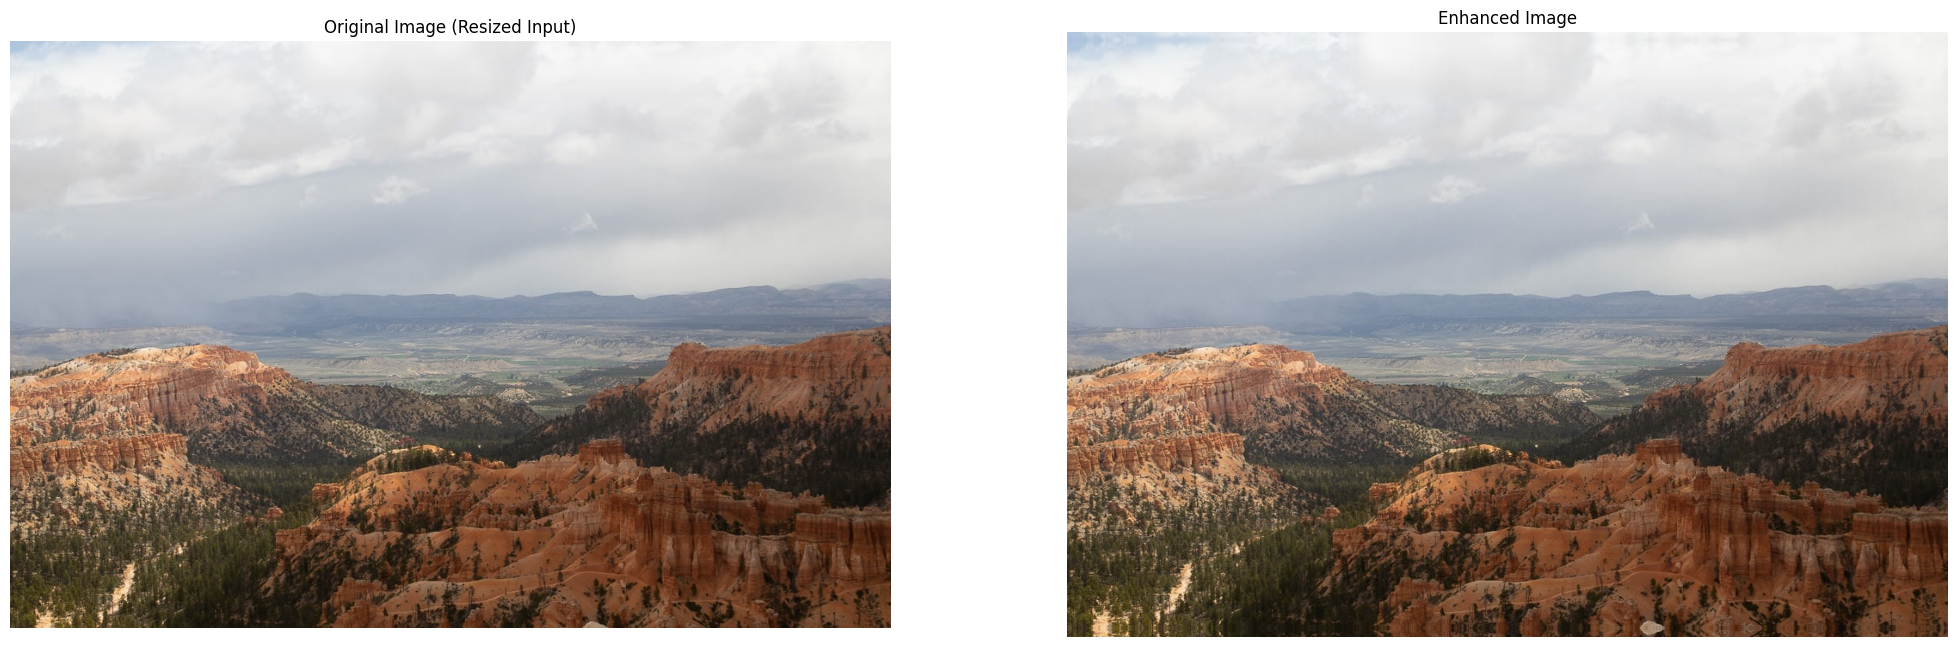

61.40098


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
from PIL import Image
from io import BytesIO


def resize(path, size):
    """Load and resize image preserving aspect ratio."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    img = Image.open(path).convert("RGB")
    w, h = img.size
    scale = size / max(w, h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    return img.resize((new_w, new_h), Image.LANCZOS)

def pre_process(pil_img):
    """Prepare image for MAXIM (divisible by 64)."""
    w, h = pil_img.size
    # Resize to be multiple of 64 for MAXIM architecture requirements
    new_w = (w // 64) * 64
    new_h = (h // 64) * 64
    if new_w != w or new_h != h:
        pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)

    img = np.asarray(pil_img, dtype=np.float32) / 255.0
    img = np.expand_dims(img, axis=0) # Add batch dim
    return img, h, w, new_h, new_w

def make_shape_even(image):
  """Pad the image to have even shapes."""
  height, width = image.shape[0], image.shape[1]
  padh = 1 if height % 2 != 0 else 0
  padw = 1 if width % 2 != 0 else 0
  image = jnp.pad(image, [(0, padh), (0, padw), (0, 0)], mode='reflect')
  return image

def load_image(filepath):
    """Load and preprocess image."""
    img = Image.open(filepath).convert("RGB")
    img = np.asarray(img, np.float32) / 255.0
    return img

def pre_process_bytes(input_file):
  '''
  Pre-process the image before sending to the model
  '''
  input_img = load_image(input_file)
  # Padding images to have even shapes
  height, width = input_img.shape[0], input_img.shape[1]
  input_img = make_shape_even(input_img)
  height_even, width_even = input_img.shape[0], input_img.shape[1]

  # padding images to be multiplies of 64
  input_img = mod_padding_symmetric(input_img, factor=64)
  input_img = np.expand_dims(input_img, axis=0)

  return input_img, height, width, height_even, width_even

def predict(input_img, task_name):
    """Run inference using the global 'state'."""
    if task_name not in TASK_NAMES:
        raise ValueError(f"Unknown task {task_name!r}; expected one of {TASK_NAMES}.")
    variables = {'params': state.params}
    if state.batch_stats is not None:
        variables['batch_stats'] = state.batch_stats

    # task_name is retained only as a user-facing label; routing receives
    # decoder tokens and never receives the task identity.
    predictions, dense_router_probs, sparse_gates = state.apply_fn(
        variables, input_img, train=False, dense_routing=False
    )
    return predictions[-1][-1]

def post_process(pred, h_orig, w_orig, h_even, w_even):
    """Convert prediction back to PIL image."""
    pred = np.array(pred[0]) # Remove batch dim
    pred = np.clip(pred, 0.0, 1.0)
    pred = (pred * 255).astype(np.uint8)
    return Image.fromarray(pred)

# --- Main Execution ---
# path = "/content/gdrive/MyDrive/Facultad/tesis/test_imgs/IMG_6425.JPG"
path = False
PREDICT_TASK = "enhance"

# url = "https://phototraces.b-cdn.net/wp-content/uploads/2021/02/id_Free_RAW_Photos_for_Editing_09_Uneditedd.jpg"
url = "https://phototraces.b-cdn.net/wp-content/uploads/2021/03/Free_RAW_Photos_for_Editing_13_Unedited.jpg"

if path and os.path.exists(path):
    # 1. Load and Resize (Using 1280 to fit in Colab memory easily, adjust if needed)
    input_pil_img = resize(path, 1280)

    # 2. Preprocess
    input_img, h, w, h_even, w_even = pre_process(input_pil_img)

    # 3. Inference
    print("Running inference...")
    preds = predict(input_img, PREDICT_TASK)

    # 4. Post-process
    result = post_process(preds, h, w, h_even, w_even)

    # 5. Visualize
    f, ax = plt.subplots(1, 2, figsize=(25, 15))

    ax[0].imshow(input_pil_img)
    ax[0].set_title("Original Image (Resized Input)")
    ax[0].axis('off')

    ax[1].imshow(result)
    ax[1].set_title("Enhanced Image")
    ax[1].axis('off')

    plt.show()
elif url:
  image_bytes = BytesIO(requests.get(url).content)
  input_img, height, width, height_even, width_even = pre_process_bytes(image_bytes)
  preds = predict(input_img, PREDICT_TASK)
  result = post_process(preds, height, width, height_even, width_even)
  f, ax = plt.subplots(1, 2, figsize=(25, 15))

  ax[0].imshow(np.array(Image.open(image_bytes)))
  ax[0].set_title("Original Image (Resized Input)")
  ax[0].axis('off')

  ax[1].imshow(result)
  ax[1].set_title("Enhanced Image")
  ax[1].axis('off')

  plt.show()
  print(compute_psnr(preds[0], input_img))

else:
    print(f"Image not found: {path}, {url}")